In [1]:
import numpy as np
import pandas as pd
import os
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt

In [2]:
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

In [3]:
# load tsv with eval data
df = pd.read_csv(f'{base_dir}/OptimalBattery/Eval_tsvs/real_cortex_parcellation.tsv', sep='\t')

Dorsolateral_PFC


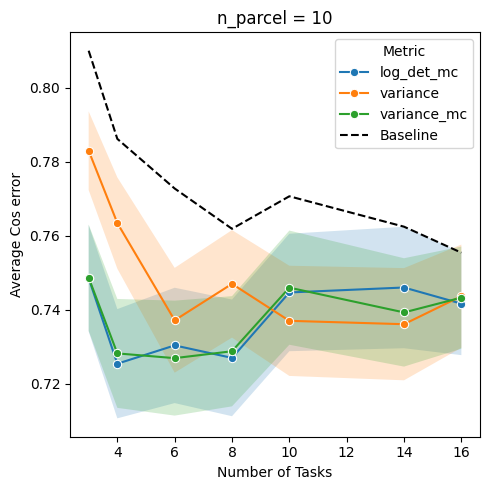

Parietal_Multisensory


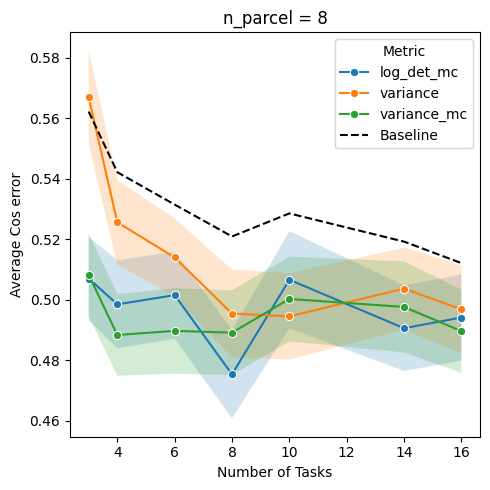

Posterior_Cingulate


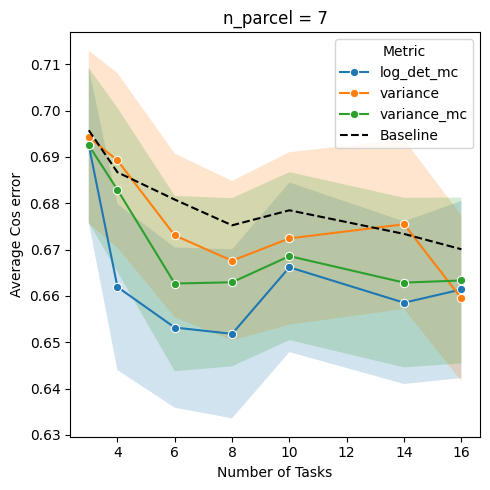

In [4]:
unique_rois = df['roi'].unique()
n_proposal_sets = 100

for roi in unique_rois:
    print(f'{roi}')
    df_roi = df[df['roi'] == roi]
    metrics = ["variance", "variance_mc", "log_det_mc"]
    resampled_results_df = plot.resample_df(df_roi, metrics, n_proposal_sets)
    expanded_results_df = plot.expand_subject_results(resampled_results_df)
    aggregated_results_df = plot.compute_aggregated_results(expanded_results_df)
    baseline_aggregated_df = plot.compute_baseline(df_roi)
    plot.plot_results(aggregated_results_df, baseline_aggregated_df)
    plt.show()